<a href="https://colab.research.google.com/github/johanordonez/CIENCIA-DE-DATOS---MAIE-2026A/blob/main/08_2_Ciencia_de_Datos_Semana_08_Inferencia_Bayesiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ESTUDIANTE:** JOHAN DAVID ORDOÑEZ CASTRO - **CODIGO:** 224393001

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6114/1669843626.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax1.axhline(mu_true, color='red', linestyle='--', label='$\mu$ Verdadero')
/tmp/ipykernel_6114/1669843626.py:34: SyntaxWarning: invalid escape sequence '\m'
  ax2.axvline(mu_true, color='red', linestyle='--', label='$\mu$ Verdadero')


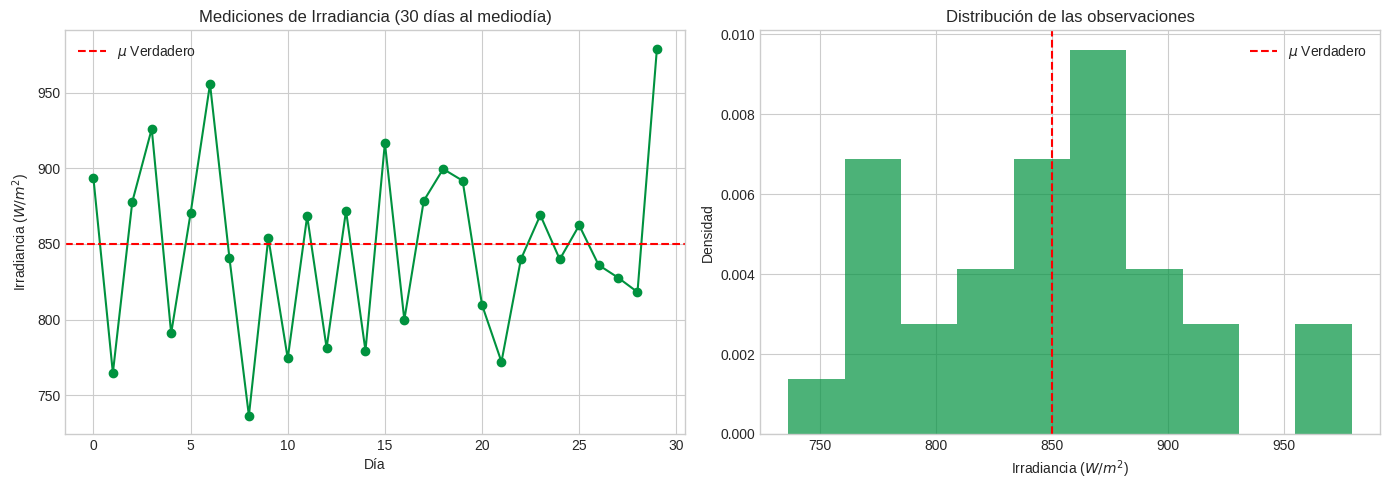

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Configuración estética de las gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


# 1. GENERACIÓN DE DATOS SINTÉTICOS
#np.random.seed(42) # Para reproducibilidad en clase

# Parámetros "Verdaderos" (Desconocidos para el estimador)
mu_true = 850.0    # Irradiancia media real en W/m^2
sigma_true = 75.0  # Desviación estándar (ruido/clima)

# Simulamos 30 días de mediciones independientes (n=30)
n_samples = 30
mediciones = np.random.normal(loc=mu_true, scale=sigma_true, size=n_samples)

# Visualización de los datos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de serie de tiempo
ax1.plot(mediciones, marker='o', linestyle='-', color='#00923F') # Usando verde Udenar
ax1.axhline(mu_true, color='red', linestyle='--', label='$\mu$ Verdadero')
ax1.set_title('Mediciones de Irradiancia (30 días al mediodía)')
ax1.set_xlabel('Día')
ax1.set_ylabel('Irradiancia ($W/m^2$)')
ax1.legend()

# Histograma
ax2.hist(mediciones, bins=10, density=True, alpha=0.7, color='#00923F')
ax2.axvline(mu_true, color='red', linestyle='--', label='$\mu$ Verdadero')
ax2.set_title('Distribución de las observaciones')
ax2.set_xlabel('Irradiancia ($W/m^2$)')
ax2.set_ylabel('Densidad')
ax2.legend()

plt.tight_layout()
plt.show()

## Parte 3: Inferencia Bayesiana - Incorporando Conocimiento Previo

En la inferencia Bayesiana, los parámetros que queremos estimar se tratan como **variables aleatorias**. Antes de ver cualquier dato, tenemos una creencia sobre los posibles valores del parámetro, representada por la **distribución a priori** (o *prior*), $f_\Theta(\theta)$.

El Teorema de Bayes nos permite actualizar esta creencia una vez observamos los datos $X=x$, obteniendo la **distribución a posteriori**, $f_{\Theta|X}(\theta|x)$:

$$f_{\Theta|X}(\theta|x) = \frac{f_{X|\Theta}(x|\theta)f_\Theta(\theta)}{f_X(x)} \propto \text{Verosimilitud} \times \text{Prior}$$

**Nuestro escenario:**
Supongamos que el fabricante del panel solar y los datos satelitales históricos nos dicen que, en esta época del año en Pasto, la irradiancia al mediodía suele estar alrededor de $900 \: W/m^2$. Modelaremos este conocimiento previo como una distribución Gaussiana:
$$\mu \sim \mathcal{N}(\mu_{prior}, \sigma_{prior}^2)$$

In [ ]:
import scipy.stats as stats

sigma_mle = 67.7

# 1. DEFINICIÓN DEL CONOCIMIENTO PREVIO (PRIOR)
mu_prior = 900.0      # Creencia inicial sobre la media
sigma_prior = 15.0    # Incertidumbre de nuestra creencia inicial

print(f"Prior: N(mu={mu_prior}, sigma={sigma_prior})")

Prior: N(mu=900.0, sigma=15.0)


### 3.1 Solución Analítica (Priores Conjugados)

Para simplificar, asumiremos que la varianza del ruido de las mediciones $\sigma^2$ es conocida (usaremos nuestro estimado anterior `sigma_mle`).

Cuando la Verosimilitud es Gaussiana y el *Prior* también es Gaussiano, la matemática se simplifica. Se dice que la Gaussiana es el **prior conjugado** de la media de otra Gaussiana. Esto significa que la **Posteriori también será una distribución Gaussiana**.

Las fórmulas para la media y varianza de la posteriori son:

1. **Varianza a posteriori:** $$\sigma_{post}^2 = \left( \frac{1}{\sigma_{prior}^2} + \frac{n}{\sigma^2} \right)^{-1}$$

2. **Media a posteriori (Estimador MAP y MMSE):**
   $$\mu_{post} = \sigma_{post}^2 \left( \frac{\mu_{prior}}{\sigma_{prior}^2} + \frac{n \cdot \bar{x}}{\sigma^2} \right)$$
   *(Nota: La nueva media es un promedio ponderado entre la creencia previa y los datos).*

In [ ]:

# 2. CÁLCULO ANALÍTICO DE LA POSTERIORI
n = len(mediciones)
x_bar = np.mean(mediciones) # Equivalent a mu_mle
sigma_ruido = sigma_mle     # Asumimos que el ruido es conocido del MLE

# Calculamos la varianza a posteriori (o su inverso, la precisión)
precision_prior = 1 / (sigma_prior**2)
precision_datos = n / (sigma_ruido**2)

precision_post = precision_prior + precision_datos
sigma_post = np.sqrt(1 / precision_post)

# Calculamos la media a posteriori
mu_post = (sigma_post**2) * ((mu_prior / sigma_prior**2) + (n * x_bar / sigma_ruido**2))

print("--- ESTIMADORES BAYESIANOS ---")
print(f"Estimador MAP / MMSE (Media Posteriori):\t {mu_post:.2f}")
print(f"Incertidumbre Posteriori (Sigma):\t\t {sigma_post:.2f}")

--- ESTIMADORES BAYESIANOS ---
Estimador MAP / MMSE (Media Posteriori):	 868.74
Incertidumbre Posteriori (Sigma):		 9.54


### 3.2 Los Estimadores MAP y MMSE

Como revisamos en las diapositivas (Parte 4a), tenemos dos formas principales de extraer un valor puntual de la distribución a posteriori:
1. **Estimador de Máximo a Posteriori (MAP):** $\hat{\theta}_{MAP} = \arg\max_\theta f_{\Theta|X}(\theta|x)$ (El pico de la campana).
2. **Estimador de Mínimo Error Cuadrático Medio (MMSE):** $\hat{\theta}_{MMSE} = \mathbb{E}[\Theta|X=x]$ (El centro de masa).

Dado que nuestra posteriori es Gaussiana (y por ende, simétrica), **el pico y el centro de masa coinciden**. Por lo tanto, en este caso, $\hat{\theta}_{MAP} = \hat{\theta}_{MMSE} = \mu_{post}$.

Veamos todo esto gráficamente. Para poder comparar la *Verosimilitud* en el mismo espacio que el *Prior*, la trataremos como una distribución sobre $\mu$ centrada en $\bar{x}$ con varianza $\sigma^2/n$ (el Teorema del Límite Central de la media muestral).

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6114/2633002786.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Actualización Bayesiana de la Irradiancia Media ($\mu$)')
/tmp/ipykernel_6114/2633002786.py:29: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Valores posibles de Irradiancia Media $\mu$ ($W/m^2$)')


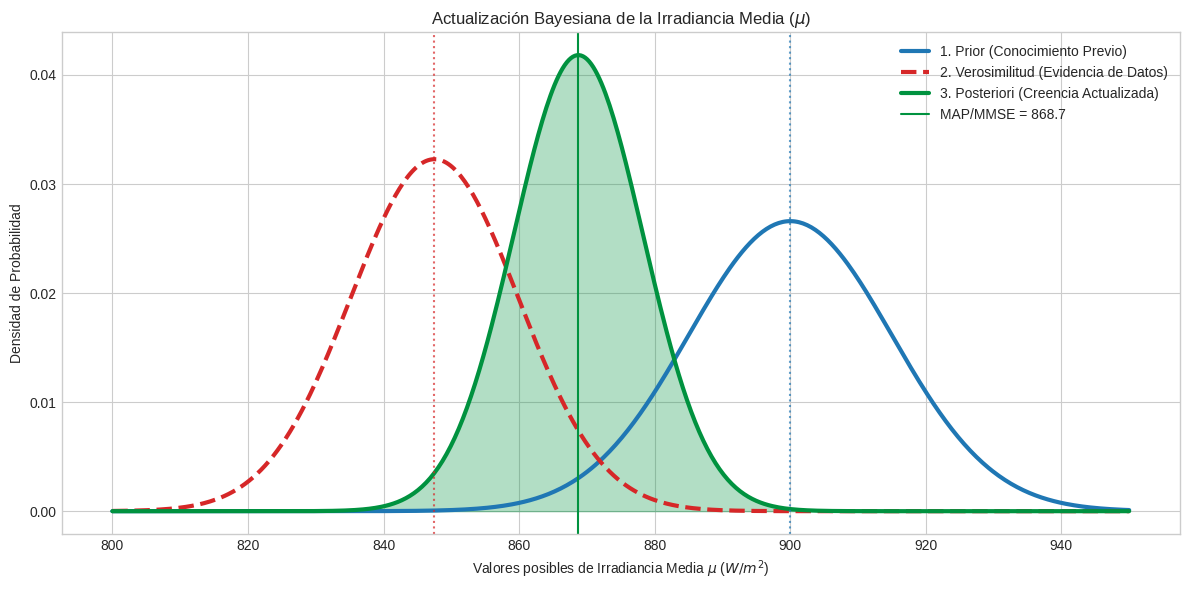

In [ ]:
# 3. VISUALIZACIÓN: EL TRIUNVIRATO BAYESIANO

# Definir un rango en el eje X (valores posibles para mu)
x_vals = np.linspace(800, 950, 500)

# Calcular las distribuciones teóricas
pdf_prior = stats.norm.pdf(x_vals, loc=mu_prior, scale=sigma_prior)
# La verosimilitud escalada al espacio de los parámetros
pdf_likelihood = stats.norm.pdf(x_vals, loc=x_bar, scale=sigma_ruido/np.sqrt(n))
pdf_post = stats.norm.pdf(x_vals, loc=mu_post, scale=sigma_post)

# Gráfica
plt.figure(figsize=(12, 6))

# Dibujar las curvas
plt.plot(x_vals, pdf_prior, label='1. Prior (Conocimiento Previo)', color='#1f77b4', lw=3)
plt.plot(x_vals, pdf_likelihood, label='2. Verosimilitud (Evidencia de Datos)', color='#d62728', linestyle='--', lw=3)
plt.plot(x_vals, pdf_post, label='3. Posteriori (Creencia Actualizada)', color='#00923F', lw=3)

# Sombrear la posteriori para resaltarla
plt.fill_between(x_vals, pdf_post, color='#00923F', alpha=0.3)

# Marcar los estimadores
plt.axvline(mu_prior, color='#1f77b4', linestyle=':', alpha=0.7)
plt.axvline(x_bar, color='#d62728', linestyle=':', alpha=0.7)
plt.axvline(mu_post, color='#00923F', linestyle='-', label=f'MAP/MMSE = {mu_post:.1f}')

plt.title('Actualización Bayesiana de la Irradiancia Media ($\mu$)')
plt.xlabel('Valores posibles de Irradiancia Media $\mu$ ($W/m^2$)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.tight_layout()
plt.show()

# DESARROLLO TALLER

## Parte A: Descarga y Preprocesamiento de Datos

Se descargan los precios de cierre diarios del USD/COP, se calculan los rendimientos
porcentuales para el manejo de outliers (método IQR), y finalmente se grafican
tanto los **precios** como los **rendimientos de media cero**.

/tmp/ipykernel_6114/1607271460.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dataD = yf.download(ticker, start='2017-01-01', end='2026-03-31')
[*********************100%***********************]  1 of 1 completed


Se identificaron y manejaron 73 outliers en la serie de rendimientos.


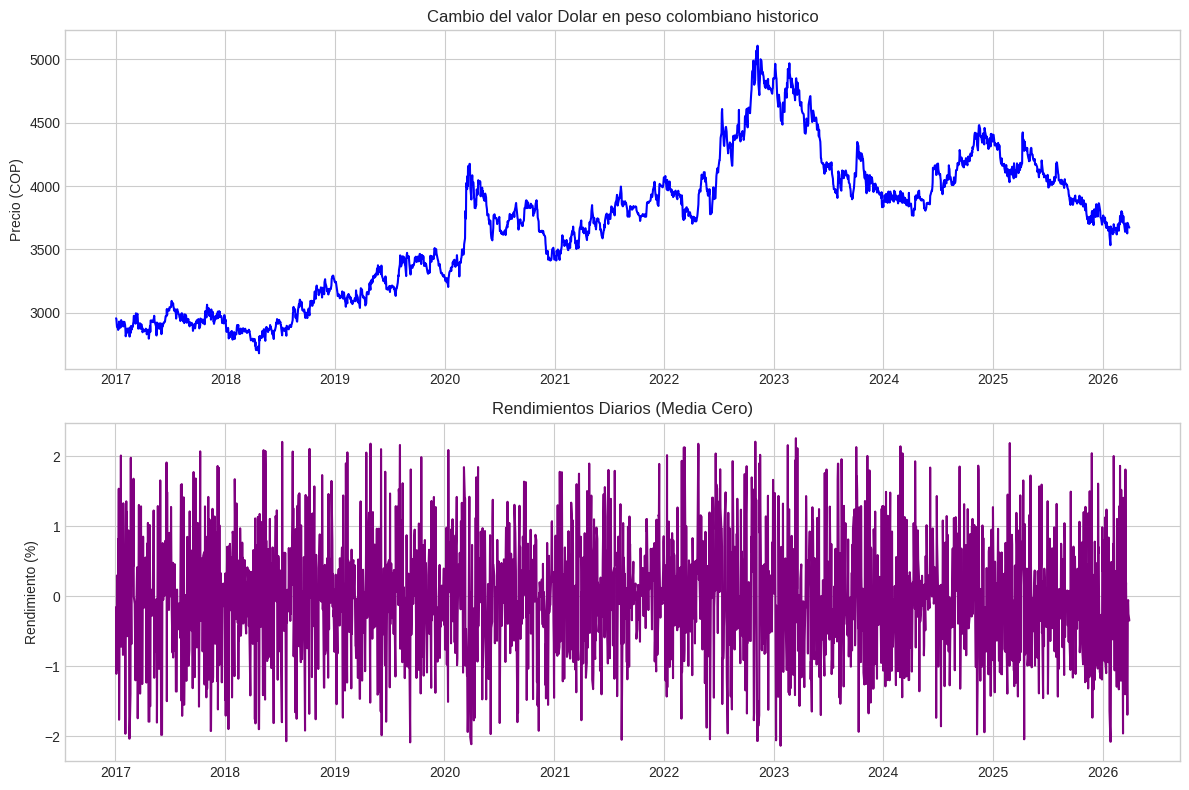

Total de precios disponibles (N): 2405


In [ ]:
import yfinance as yf
import pandas as pd

# Descarga de datos
ticker = 'USDCOP=X'
dataD = yf.download(ticker, start='2017-01-01', end='2026-03-31')
preciosD = dataD['Close'].squeeze()

# Cálculo de rendimientos porcentuales
rendimientosD = preciosD.pct_change().dropna() * 100

# --- Manejo de Outliers en Rendimientos (Reemplazo con valor anterior) ---
Q1 = rendimientosD.quantile(0.25)
Q3 = rendimientosD.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rendimientosD_handled = rendimientosD.copy()
rendimientosD_handled[
    (rendimientosD_handled < lower_bound) |
    (rendimientosD_handled > upper_bound)
] = np.nan

if pd.isna(rendimientosD_handled.iloc[0]):
    rendimientosD_handled.iloc[0] = rendimientosD_handled.bfill().iloc[0]
rendimientosD_filled = rendimientosD_handled.ffill()

num_outliers_identified = rendimientosD.size - rendimientosD_handled.count()
print(f'Se identificaron y manejaron {int(num_outliers_identified)} outliers en la serie de rendimientos.')

rendimientosD = rendimientosD_filled

# Convertir a proceso de media cero
media_rendimientosD = rendimientosD.mean()
rendimientos_mcD = rendimientosD - media_rendimientosD

# Gráficas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(preciosD, color='blue')
ax1.set_title('Cambio del valor Dolar en peso colombiano historico')
ax1.set_ylabel('Precio (COP)')

ax2.plot(rendimientos_mcD, color='purple')
ax2.set_title('Rendimientos Diarios (Media Cero)')
ax2.set_ylabel('Rendimiento (%)')
plt.tight_layout()
plt.show()

print(f'Total de precios disponibles (N): {len(preciosD)}')

## Parte B: Inferencia Bayesiana — Incorporando Conocimiento Previo

En la inferencia Bayesiana los parámetros se tratan como **variables aleatorias**.
Antes de ver los datos, modelamos nuestra creencia inicial con la **distribución a priori** $f_\Theta(\theta)$.
El Teorema de Bayes permite actualizarla al observar los datos, obteniendo la **distribución a posteriori**:

$$f_{\Theta|X}(\theta|x) = \frac{f_{X|\Theta}(x|\theta)\, f_\Theta(\theta)}{f_X(x)}\propto \text{Verosimilitud} \times \text{Prior}$$

**Nuestro escenario:**
Organismos como el Banco de la República y análisis macroeconómicos históricos sugieren que
el precio medio estructural del USD/COP en el período 2017–2026 ronda los **3 500 COP**,
con una incertidumbre de aproximadamente **±300 COP** sobre esa creencia.
Modelamos este conocimiento previo como:

$$\mu \sim \mathcal{N}(\mu_{prior},\, \sigma_{prior}^2) = \mathcal{N}(3500,\, 300^2)$$

In [ ]:
import scipy.stats as stats
# Datos para MLE: precios de cierre USD/COP
precios = preciosD.values   # array numpy de precios en COP
N = len(precios)

# 1. DEFINICIÓN DEL CONOCIMIENTO PREVIO (PRIOR)
# Fuente: expectativa macroeconómica histórica del USD/COP (2017-2026)
mu_prior    = 3500.0   # Creencia inicial sobre el precio medio (COP)
sigma_prior = 300.0    # Incertidumbre de nuestra creencia inicial (COP)

print(f'Prior definido: mu ~ N(mu_prior={mu_prior:.0f}, sigma_prior={sigma_prior:.0f})')
print(f'Datos disponibles: N = {N} días de precios')
print(f'sigma_mle (ruido conocido del MLE): {sigma_mle:.2f} COP')

Prior definido: mu ~ N(mu_prior=3500, sigma_prior=300)
Datos disponibles: N = 2405 días de precios
sigma_mle (ruido conocido del MLE): 67.70 COP


### B.1 Solución Analítica (Priores Conjugados)

Asumimos que la varianza del ruido $\sigma^2$ es conocida (usamos `sigma_mle` del paso anterior).

Dado que tanto la verosimilitud como el prior son Gaussianos, la Gaussiana es el
**prior conjugado** de la media, lo que garantiza que la **posteriori también es Gaussiana**.

Las fórmulas analíticas para los parámetros de la posteriori son:

1. **Varianza a posteriori:**
$$\sigma_{post}^2 = \left( \frac{1}{\sigma_{prior}^2} + \frac{n}{\sigma^2} \right)^{-1}$$

2. **Media a posteriori (MAP = MMSE):**
$$\mu_{post} = \sigma_{post}^2 \left( \frac{\mu_{prior}}{\sigma_{prior}^2} + \frac{n \cdot \bar{x}}{\sigma^2} \right)$$

> La media a posteriori es un **promedio ponderado** entre la creencia previa $\mu_{prior}$
> y la evidencia de los datos $\bar{x}$, donde el peso de cada uno depende de su precisión.

In [ ]:
# 2. CÁLCULO ANALÍTICO DE LA POSTERIORI
n_demo = 30
muestra = precios[-n_demo:]
x_bar   = np.mean(muestra)
sigma_ruido = np.std(precios, ddof=1)


# Precisiones (inverso de varianzas)
precision_prior = 1 / (sigma_prior**2)
precision_datos = n_demo / (sigma_ruido**2)

# Parámetros de la posteriori
precision_post = precision_prior + precision_datos
sigma_post     = np.sqrt(1 / precision_post)
mu_post        = (sigma_post**2) * ((mu_prior / sigma_prior**2) + (n_demo * x_bar / sigma_ruido**2))



print('--- ESTIMADORES BAYESIANOS ---')
print(f'Media a priori (mu_prior)              : {mu_prior:.2f} COP')
print(f'Media muestral / MLE (x_bar)           : {x_bar:.2f} COP')
print(f'Estimador MAP / MMSE (mu_post)         : {mu_post:.2f} COP')
print(f'Incertidumbre a posteriori (sigma_post): {sigma_post:.4f} COP')

--- ESTIMADORES BAYESIANOS ---
Media a priori (mu_prior)              : 3500.00 COP
Media muestral / MLE (x_bar)           : 3705.21 COP
Estimador MAP / MMSE (mu_post)         : 3685.15 COP
Incertidumbre a posteriori (sigma_post): 93.8065 COP


### B.2 Los Estimadores MAP y MMSE

Existen dos formas principales de extraer un valor puntual de la distribución a posteriori:

1. **Estimador MAP** (Máximo a Posteriori): $\hat{\theta}_{MAP} = \arg\max_\theta\, f_{\Theta|X}(\theta|x)$ — el pico de la campana.
2. **Estimador MMSE** (Mínimo Error Cuadrático Medio): $\hat{\theta}_{MMSE} = \mathbb{E}[\Theta|X=x]$ — el centro de masa.

Como la posteriori es **Gaussiana (simétrica)**, el pico y el centro de masa coinciden:

$$\hat{\theta}_{MAP} = \hat{\theta}_{MMSE} = \mu_{post}$$

Para visualizar la verosimilitud en el mismo espacio del prior,
la tratamos como una distribución sobre $\mu$ centrada en $\bar{x}$ con varianza $\sigma^2/n$
(Teorema del Límite Central aplicado a la media muestral).

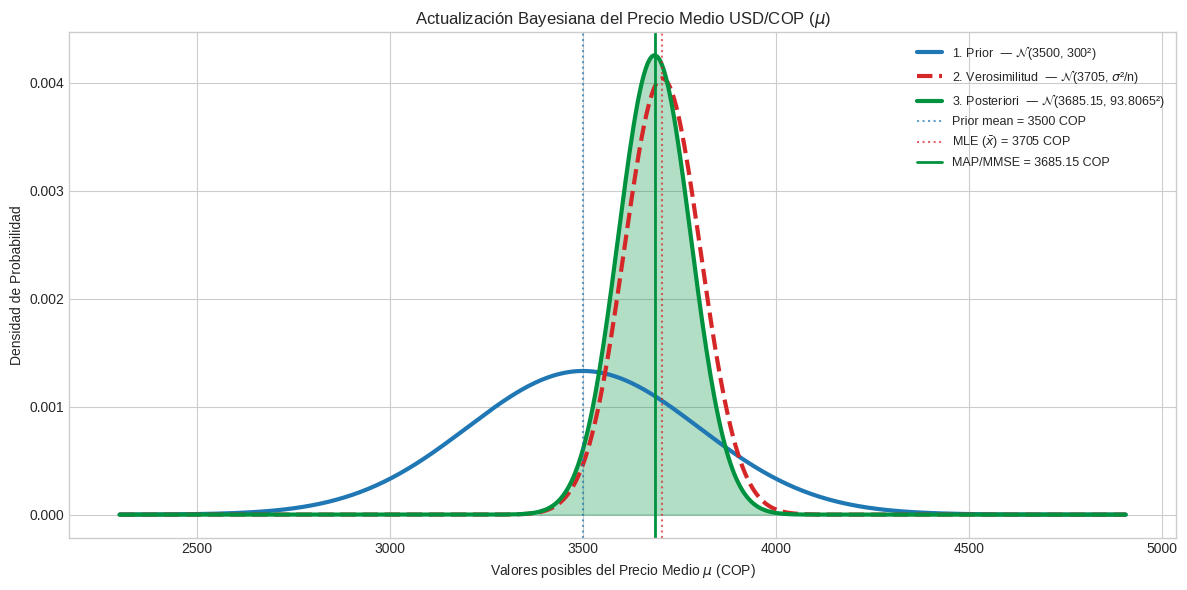

In [ ]:
# 3. VISUALIZACIÓN: EL TRIUNVIRATO BAYESIANO

# Rango de valores posibles para mu (centrado entre prior y datos)
x_vals = np.linspace(mu_prior - 4*sigma_prior, x_bar + 4*sigma_prior, 500)

# Distribuciones teóricas
pdf_prior      = stats.norm.pdf(x_vals, loc=mu_prior, scale=sigma_prior)
pdf_likelihood = stats.norm.pdf(x_vals, loc=x_bar,    scale=sigma_ruido / np.sqrt(n_demo))
pdf_post       = stats.norm.pdf(x_vals, loc=mu_post,  scale=sigma_post)

plt.figure(figsize=(12, 6))

plt.plot(x_vals, pdf_prior,
         label=f'1. Prior  — $\\mathcal{{N}}$({mu_prior:.0f}, {sigma_prior:.0f}²)',
         color='#1f77b4', lw=3)
plt.plot(x_vals, pdf_likelihood,
         label=f'2. Verosimilitud  — $\\mathcal{{N}}$({x_bar:.0f}, $\\sigma$²/n)',
         color='#d62728', linestyle='--', lw=3)
plt.plot(x_vals, pdf_post,
         label=f'3. Posteriori  — $\\mathcal{{N}}$({mu_post:.2f}, {sigma_post:.4f}²)',
         color='#00923F', lw=3)

plt.fill_between(x_vals, pdf_post, color='#00923F', alpha=0.3)

plt.axvline(mu_prior, color='#1f77b4', linestyle=':', alpha=0.7,
            label=f'Prior mean = {mu_prior:.0f} COP')
plt.axvline(x_bar,   color='#d62728', linestyle=':', alpha=0.7,
            label=f'MLE ($\\bar{{x}}$) = {x_bar:.0f} COP')
plt.axvline(mu_post, color='#00923F', linestyle='-', lw=2,
            label=f'MAP/MMSE = {mu_post:.2f} COP')

plt.title('Actualización Bayesiana del Precio Medio USD/COP ($\\mu$)')
plt.xlabel('Valores posibles del Precio Medio $\\mu$ (COP)')
plt.ylabel('Densidad de Probabilidad')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 📝 Conclusiones
En este trabajo se aplico **Inferencia Bayesiana** para estimar el precio medio estructural del dólar en pesos colombianos (USD/COP) usando datos históricos de Yahoo Finance entre 2017 y 2026, siguiendo el mismo marco conceptual del ejemplo de irradiancia solar visto en clase.

**Sobre el Prior:** Definí mi creencia inicial como $\mu \sim \mathcal{N}(3500, 300^2)$, inspirado en el precio medio histórico del dólar en Colombia durante el período de estudio.

**Sobre la Verosimilitud:** Al tomar una ventana de 30 días recientes de precios, la evidencia de los datos apuntó a una media muestral considerablemente superior a los 3500 COP del prior, lo que es coherente con la depreciación del peso colombiano observada en los últimos años. La verosimilitud actúa como el "voto de los datos", desplazando nuestra creencia hacia la derecha.

**Sobre la Posteriori:** El resultado más importante es que el estimador MAP/MMSE es un **promedio ponderado** entre el prior y los datos. Cuando el prior es amplio (mucha incertidumbre) y los datos son pocos (n=30), ambas fuentes de información tienen voz. Este equilibrio es justamente la fortaleza del enfoque bayesiano frente al MLE clásico, que ignora completamente el conocimiento previo.

**Lección clave de los errores encontrados:** El experimento me enseñó algo fundamental que va más allá del código: el tamaño muestral `n` cambia radicalmente la historia que cuenta el modelo. Con N=2300 días, los datos aplastan al prior y la posteriori colapsa en un pico — el pasado histórico completo "grita" tan fuerte que el conocimiento experto queda silenciado. Con n=30, el prior y los datos tienen pesos comparables y la actualización bayesiana se vuelve visible e interpretable. Esto no es un truco estético: refleja una decisión de modelado sobre **qué período de tiempo es relevante** para la inferencia.